# Ejercicio de Feedback Regresiones y Random Forest

## Regresión lineal

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from scipy.stats import shapiro
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import linear_reset, het_breuschpagan, het_white
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Cargo el dataset
df=pd.read_csv('precio_casas.csv')

Apartado 1.1
Calcular la media y la varianza de la variable “size” del dataset. Dibujar este histograma
incluyendo la media y la desviación estándar y realizar una breve interpretación de la
distribución.

In [3]:
# Defino las variables a utilizar 
size, price, loc, num_rooms = df['size'], df['price'], df['location_index'], df['num_rooms']
mean, std_dev = np.mean(size), np.std(size)
print(f"Mean size: {mean}, Standard Deviation: {std_dev}")

Mean size: 97.28, Standard Deviation: 43.51920955164512


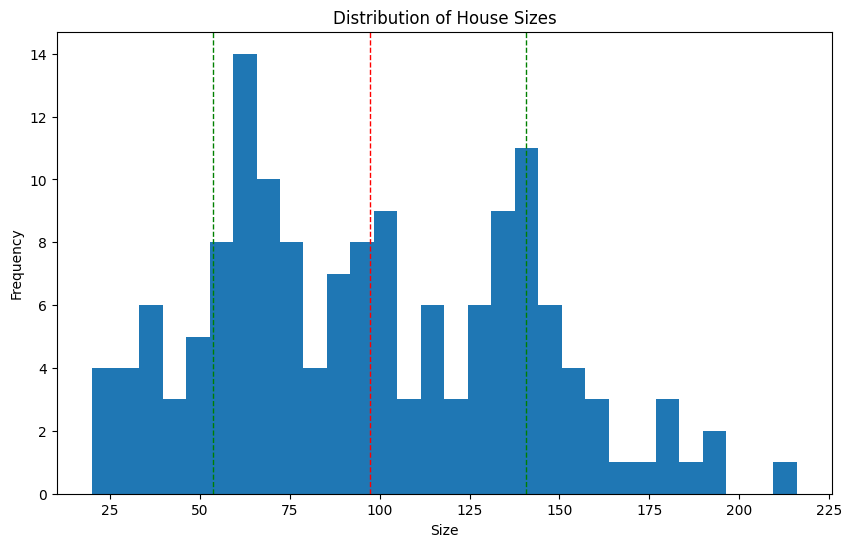

In [4]:
# Creo un histograma para visualizar la distribución de los tamaños de las casas
plt.figure(figsize=(10, 6))
plt.hist(x = size, bins=30)
plt.axvline(mean, color='r', linestyle='dashed', linewidth=1)
plt.axvline(mean + std_dev, color='g', linestyle='dashed', linewidth=1)
plt.axvline(mean - std_dev, color='g', linestyle='dashed', linewidth=1)
plt.title('Distribution of House Sizes')
plt.xlabel('Size')
plt.ylabel('Frequency')
plt.show()

En este histograma se muestra la frecuencia para cada uno de los tamaños de vivienda, mostrando con una línea roja la media, que se ubica alrededor de 100 metros cuadrados. La mayoría de los valores se encuentran entre las líneas verdes (la media +- una desviación estándar), lo que sugiere que los tamaños más comunes se encuentran en el rango de aproximadamente 50 m² a 140 m².

Apartado 1.2
Realizar un gráfico de dispersión (scatter plot) de la variable size frente a la variable price, y de
la variable location_index frente a la variable price. A priori, en términos de una regresión
lineal simple, ¿cuál de las dos variables elegirías como variable predictora para el desarrollo del
modelo, tomando como variable objetivo la variable price?

<Axes: xlabel='size', ylabel='price'>

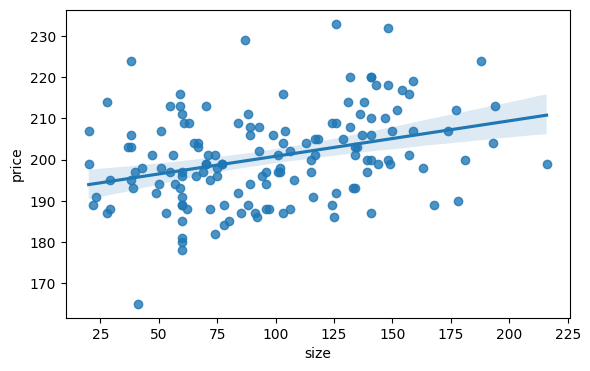

In [5]:
#plt.scatter(size, price)
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.regplot(x=size, y=price, data=df, ax = ax)

<Axes: xlabel='location_index', ylabel='price'>

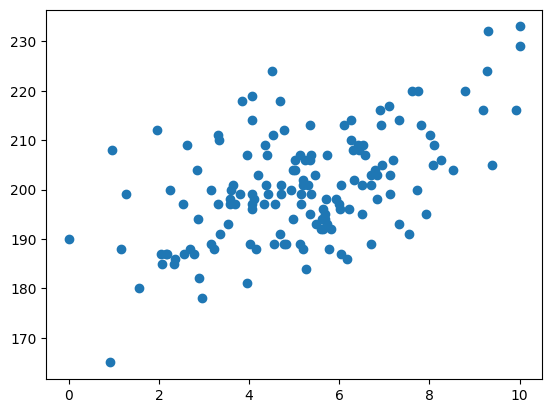

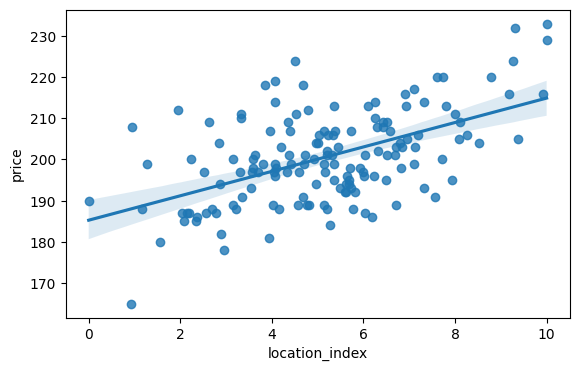

In [6]:
plt.scatter(loc, price)
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.regplot(x=loc, y=price, data=df, ax = ax)

En el primer gráfico, se puede observar una dispersión mayor de los valores, esto ocurre porque el precio no solo viene determinado por el tamaño del inmueble, sino más bien de la zona en donde se encuentra, que determina el precio por metro cuadrado del mismo. Esto, puede observarse al notar la existencia de pisos pequeños, entorno a los 25-30 metros cuadrados con precios con una variabilidad muy alta, de menos de 170 mil euros y luego otro de mas de 220 mil euros. Lo mismo ocurre con pisos mas grandes.

Por otro lado, en el segundo gráfico de dispersión, se puede obervar una fuerte correlación positiva entre el índice de ubicación y el precio, ya que a medida que el 'location_index' aumenta, el precio tiende a aumentar también, sugiriendo zonas de mayor demanda. Además, la dispersión de los datos es mucho menor que en el primer gráfico, puesto que el rango de precios para cualquier 'location_index' es mucho más pequeño que el rango de precios para un tamaño dado, lo cual nos permite predecir el precio con mucha más precisión a partir de un 'location_index'. Teniendo esto en cuenta, la variable 'location_index' funcionará mucho mejor como un predictor en el modelo de predicción.

Tras ver ambos grafícos de dispersión, es razonable pensar que la variable 'location_index' funciona mejor como predictora del precio, puesto que si se tiene como variable única predictora el tamaño, la predicción del precio resulta ser muy incierta debido a la alta dispersión de los datos.

Apartado 1.3
Desarrolla un modelo de regresión lineal con la variable location_index, tomando un 80% del
conjunto inicial como conjunto de entrenamiento y “135” como semilla en la división de
conjunto de entrenamiento y test. Evalúa los supuestos del modelo. ¿Qué ocurre con el Test
Reset de Ramsey? ¿Qué consecuencias en este caso puede tener el resultado del Test Reset de
Ramsey en nuestro modelo?

In [9]:
# Se crea un conjunto de datos de entrenamiento (80%) y otro de prueba (20% restante)
X_train, X_test, y_train, y_test = train_test_split(
    loc.to_frame(),
    price,
    test_size=0.2, 
    random_state=135
)
X_train_cte = sm.add_constant(X_train)
# Se crea el modelo de regresión lineal
model = sm.OLS(y_train, X_train_cte).fit()

print(model.summary())
# Evaluar lso supuestos del modelo.
residuals = model.resid


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.303
Method:                 Least Squares   F-statistic:                     52.61
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           4.63e-11
Time:                        12:27:46   Log-Likelihood:                -436.86
No. Observations:                 120   AIC:                             877.7
Df Residuals:                     118   BIC:                             883.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            184.1266      2.420     76.

Dado que un modelo ha de cumplir unos supuestos antes de asumir su validez, debido a que a pesar de que la regresión siempre se puede llevar a cabo por mínimos cuadrados y cumplirá y𝐸(ϵ) = 0
o incluso puede ser que las métricas de calidad del modelo sean satisfactorias, esta es una condición necesaria, pero no suficiente.
Para asegurar el cumplimiento de estos supuestos, se ha realizado un contraste de hipótesis para cada uno de los siguientes supuestos, encontrados en el tema 1:
- Linealidad (Test RESET de Ramsey)
- Homocedasticidad (Test de Breusch-Pagan y Test de White)
- Normalidad (Test de Saphiro-Wilk)
- Independencia de residuos (Test de Durbin-Watson)


In [12]:
# Ramsey’s RESET test for neglected nonlinearity
ramsey = linear_reset(model, power=2, use_f=True)
print("Ramsey's RESET test:", ramsey)

Ramsey's RESET test: <F test: F=4.211834698661424, p=0.04237398249228712, df_denom=117, df_num=1>


Asumiendo un nivel de significancia α = 0.05, se evaluó el cumplimiento del supuesto de linealidad en base a las siguientes hipótesis:
- ($H_0$): El modelo explica de forma correcta con valores lineales.
- ($H_1$): Hay que recurrir a valores no lineales para predecir la variable. 

En base a esto, se ha decidido no rechazar la hipótesis nula, ya que el **p-valor (0.3859)** es superior al nivel de significancia. Por lo tanto, esto significa que la relación entre las variables 'location_index' y 'price' es lineal. 

In [13]:
# Breusch-Pagan Lagrange Multiplier test for heteroscedasticity
res = []
res = het_breuschpagan(model.resid, model.model.exog)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, res)))

{'Lagrange multiplier statistic': np.float64(0.2878629128964061), 'p-value': np.float64(0.5915932918470932), 'f-value': np.float64(0.2837458636049684), 'f p-value': np.float64(0.5952581862688073)}


Asumiendo un nivel de significancia α = 0.05, se evaluó el cumplimiento del supuesto de homocedasticidad en base a las siguientes hipótesis:
- ($H_0$): Los residuos son homocedásticos.
- ($H_1$): Los residuos no son homocedásticos. 

En base a esto, se ha decidido no rechazar la hipótesis nula, ya que el **p-valor** del test F y del test X² es superior al nivel de significancia. Por lo tanto, esto significa que el modelo no presenta errores de varianza no constante en el error, y que por tanto los errores estándar y los test de significancia son confiables.

In [14]:
het_white(model.resid, model.model.exog)
print("lagrange multiplier statistic:", res[0]) # The lagrange multiplier statistic.
print("p-value:", res[1]) # The p-value of lagrange multiplier test
print("f-value:", res[2]) # The f-statistic of the hypothesis that the error variance does not depend on x. This is an alternative test variant not the original LM test.
print("f p-value:", res[3]) # The p-value for the f-statistic.

lagrange multiplier statistic: 0.2878629128964061
p-value: 0.5915932918470932
f-value: 0.2837458636049684
f p-value: 0.5952581862688073


De manera alternativa, se ha usado el test de het_white y la interpretación de los valores obtenidos nos lleva a la misma conclusión, puesto de el p-valor (F-statistic) y el p-valor (LM) es mayor que el nivel de significancia.

In [15]:
shapiro_test = shapiro(residuals)
print("Shapiro-Wilk Test:", shapiro_test)

Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.9892574834295614), pvalue=np.float64(0.47038136084651727))


Asumiendo un nivel de significancia α = 0.05, se evaluó el cumplimiento del supuesto de normalidad en base a las siguientes hipótesis:
- ($H_0$): La distribución de los valores estudiados es normal.
- ($H_1$): La distribución de los valores estudiados no es normal. 

En base a esto, se ha decidido no rechazar la hipótesis nula, ya que el **p-valor** del test F y del test X² es superior al nivel de significancia. Por lo tanto, esto significa que el modelo no presenta errores de varianza no constante en el error, y que por tanto los errores estándar y los test de significancia son confiables.

In [16]:
durbin_watson_stat = durbin_watson(residuals)
print("Durbin-Watson statistic:", durbin_watson_stat)

Durbin-Watson statistic: 1.8102373919411727


Asumiendo un nivel de significancia α = 0.05, se evaluó el cumplimiento del supuesto de independencia de residuos en base a las siguientes hipótesis:
- ($H_0$): No existe autocorrelación entre los residuos.
- ($H_1$): Existe autocorrelación entre los residuos. 

Antes de realizar el análisis, es importante destacar que en este caso al usar durbin_watson no se está comparando un p-valor con α, sino que se interpreta por la proximidad del estadístico al valor 2.0.

Como el valor obtenido fue 1.81, siguiendo la interpretación de los resultados mostrada en statsmodels.stats.stattools.durbin_watson, nos encontramos con un valor muy cercano a 2, que está entre 0 y 4, valores que indican que no hay correlación serial y que hay una correlación fuerte negativa respectivamente. Como el valor obtenido es más o menos central, no existe una correlación serial positiva ni negativa, lo que muestre que los errores en las predicciones son independientes entre sí.

Conclusión: No se rechaza la hipótesis nula puesto que no hay evidencia para hacerlo y se cumple el supuesto de independencia de los residuos.


Apartado 1.4
Tomando como variables de entrada todas las variables menos la variable objetivo, desarrolla
un modelo de regresión lineal múltiple, de nuevo fijando los parámetros de división de
entrenamiento y prueba del apartado anterior. Evalúa los supuestos del modelo e interpreta
brevemente los resultados. Calcula el R² del modelo. ¿Crees que es un valor de calidad
confiable?

In [19]:
# Uno mis variables previamente definidas
X_multiple = pd.concat([size, loc, num_rooms], axis=1)
# Divido el conjunto de datos en train y test como antes
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_multiple,
    price,
    test_size=0.2, 
    random_state=135
)
model = sm.OLS(y_train2, sm.add_constant(X_train2)).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     181.1
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           1.35e-43
Time:                        16:30:41   Log-Likelihood:                -354.74
No. Observations:                 120   AIC:                             717.5
Df Residuals:                     116   BIC:                             728.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            130.5439      3.204     40.

In [ ]:
# Test RESET de Ramsey
ramsey = linear_reset(model, power=2, use_f=True)
print("Ramsey's RESET test:", ramsey)

# Test de Breusch-Pagan
res = het_breuschpagan(model.resid, model.model.exog)
print("Test de Breusch-Pagan:")
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(labels, res)))
# Test de White
print("Test de White:")
res = het_white(model.resid, model.model.exog)
print("lagrange multiplier statistic:", res[0]) # The lagrange multiplier statistic.
print("p-value:", res[1]) # The p-value of lagrange multiplier test
print("f-value:", res[2]) # The f-statistic of the hypothesis that the error variance does not depend on x. This is an alternative test variant not the original LM test.
print("f p-value:", res[3]) # The p-value for the f-statistic.

# Test de Shapiro-Wilk
shapiro_test = shapiro(model.resid)
print("Shapiro-Wilk Test:", shapiro_test)

# Test de Durbin-Watson
durbin_watson_stat = durbin_watson(model.resid)
print("Durbin-Watson statistic:", durbin_watson_stat)


Ramsey's RESET test: <F test: F=0.7575508987248349, p=0.3859092370483398, df_denom=115, df_num=1>
{'Lagrange multiplier statistic': np.float64(2.3629274627225216), 'p-value': np.float64(0.5005729691871643), 'f-value': np.float64(0.7766814201335317), 'f p-value': np.float64(0.50930184504532)}
lagrange multiplier statistic: 16.699820985123303
p-value: 0.053629581751490345
f-value: 1.975881601542167
f p-value: 0.04875531000999154
Shapiro-Wilk Test: ShapiroResult(statistic=np.float64(0.9896838244719832), pvalue=np.float64(0.5065491211246371))
Durbin-Watson statistic: 1.7485095524024568


Asumiendo como antes un nivel de significancia de alpha = 0.05 se analizan los supuestos de forma breve:
- El supuesto de linealidad se cumple, ya que el p-valor (F-test) es mayor que el nivel de significancia. Por lo tanto no se rechaza la hipótesis nula.
- El supuesto de normalidad de los residuos se cumple, ya que el p-valor es mayor al nivel de significancia.
- El supuesto de homocedasticidad se cumple, aunque en términos estrictos el p-valor (F-statistic) en el test de White está muy próximo al nivel de significancia, lo que podría indicar una ligera heterocedasticidad. A pesar de esto el valor es menor que el valor del nivel de significancia, además de que el p-valor (LM) es mayor que el nivel de significancia.
- El supuesto de independencia de los residuos se cumple como en el caso del apartado anterior, con un valor próximo a 2.

In [22]:

mae = mean_absolute_error(y_test2, model.predict(sm.add_constant(X_test2)))
print("Mean Absolute Error:", mae)
mse = mean_squared_error(y_test2, model.predict(sm.add_constant(X_test2)))
print("Mean Squared Error:", mse)
r2 = r2_score(y_test2, model.predict(sm.add_constant(X_test2)))
print("R²:", r2)

Mean Absolute Error: 2.815004970479139
Mean Squared Error: 12.957098082783409
R²: 0.8958702348042659


Al analizar estos resultados, se puede concluir que el poder predictivo del modelo es muy alto, ya que el R² indica que el modelo explica el 89.58 de la variabilidad total en la variable objetivo. A pesar de esto, y aunque esta métrica es bastante confiable, se detectó una ligera heterocedasticidad que tiene impacto en los p-valores de las variables, por lo que hacen que no sean del todo confiables.

## Regresión Logística

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.metrics import roc_curve, auc

In [2]:
df=pd.read_csv('deteccion_cancer.csv')
df.head()

,radius,texture,concavity,Diagnosis
0,17.99,10.38,0.3001,1
1,20.57,17.77,0.0869,1
2,19.69,21.25,0.1974,1
3,11.42,20.38,0.2414,1
4,20.29,14.34,0.1980,1


¿Cuál es la probabilidad de que extrayendo una observación del dataset ocurra que tomemos
un nevus maligno? ¿Cuál es el odd asociado a este suceso (extraer una observación donde el nevus es maligno)? ¿Y el log-odd? (Recuerda que para calcular el logaritmo neperiano de un
valor en Python utilizamos la función np.log( )).𝑥0𝑥0

In [3]:
feature_cols = ['radius', 'texture', 'concavity']
X = df[feature_cols]
y = df['Diagnosis']

# Se calcula la probabilidad P como el número de casos positivos sobre el total de casos
P = y.sum() / len(y)

odd = P / (1 - P)
print(f"Probability P: {P}\nOdds: {odd}")
print(f"Log-Odds: {np.log(odd)}")

Probability P: 0.37258347978910367
Odds: 0.5938375350140055
Log-Odds: -0.5211495071076269


Para calcular la probabilidad de que extrayendo una observación del dataset se trate de un nevus maligno es necesario calcular el número de casos positivos (donde el valor es 1), dividido entre el número de casos totales. El valor obtenido sugiere que la probabilidad de que uno de los registros escogidos al azar tenga un nevus maligno es del 37,25%.

Por otra parte, el odd de tener un nevus maligno es de 0.59 a 1, lo que sugiere que es más probable que el nevus sea benigno que maligno.

El logaritmo natural del odd indica que la probabilidad del evento menos favorable (en este caso que el nevus sea maligno) es menor que 0.5.

Apartado 2.2
Calcula 3 regresiones logísticas simples utilizando las 3 variables predictoras de la tabla
(tomando como variable objetivo Diagnosis), formulando en los 3 casos un conjunto de test
que suponga el 25% de las observaciones totales con la semilla “135”. En un supuesto de
regresión logística simple, basado en la métrica gini, ¿qué variable predice mejor el cáncer?

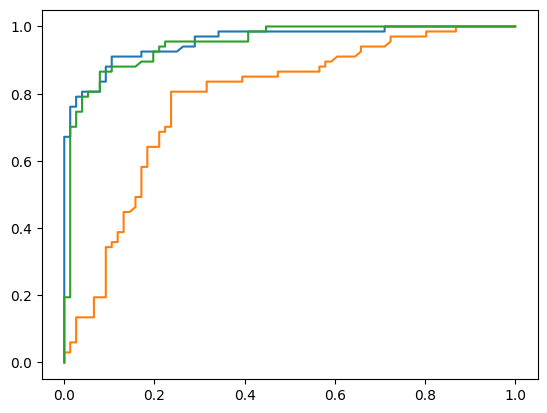

In [4]:
for feature in feature_cols:
    X_train, X_test, y_train, y_test = train_test_split(df[feature], 
                                                        df['Diagnosis'], 
                                                        test_size=0.25, 
                                                        random_state=135
                                                        )
    model = LogisticRegression()
    model.fit(X_train.to_frame(), y_train)
    y_pred_prob = model.predict_proba(X_test.to_frame())[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'{feature} (AUC = {roc_auc:.2f})')

Apartado 2.3
Realiza una regresión logística múltiple utilizando las 3 variables en un mismo modelo,
tomando como parámetros de la regresión logísticas los mismos que en el apartado anterior.
Dibuja la curva ROC. Indica la ganancia o pérdida de gini de la regresión logística múltiple con
respecto a los tres modelos desarrollados en el apartado anterior.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
                                                    df[feature_cols],
                                                    df['Diagnosis'],
                                                    test_size=0.25,
                                                    random_state=135
                                                    )
model = LogisticRegression()


Apartado 2.4
Si tuvieras que valorar definir un umbral para el modelo desarrollado, ¿en qué métrica te
basarías? Random Forest Utilizando el mismo dataframe que en el apartado anterior

## Random Forest

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

Apartado 3.1
Entrena un árbol de clasificación, utilizando un conjunto de testeo del 20% (continuando con la
semilla “135”), con una profundidad máxima de 7 y un número mínimo de observaciones por
split de 10. Obtén sus métricas de precisión, recall y f1-score.


Apartado 3.2
Entrena un Random Forest con 100 estimadores y una profundidad máxima de 6, con el mismo
conjunto de entrenamiento y prueba que el apartado anterior. Fija la misma semilla en el
desarrollo del modelo (“135”). Dibuja su curva ROC asociada. Obtén sus métricas de precisión,
recall y f1-score. Haz una comparativa con los resultados del modelo de árbol de clasificación
del apartado anterior. ¿Qué modelo predice mejor de todos los desarrollados en los dos
últimos apartados? ¿Cuál crees que pueden ser las causas de que dicho modelo tenga un mejor
rendimiento?